## Exploratory Data Analysis

##### TODO
- organise files and folders
- split config and settings
- create file with functions
- organise Results

#### Configuration

In [65]:
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import mysql.connector
from mysql.connector import Error

#_____________________________________________________
from dotenv import load_dotenv
import os 
load_dotenv()  # reads .env file
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
#_____________________________________________________

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime
from IPython.display import display, HTML
from urllib.parse import urlsplit

#### Functions

In [66]:
# Tables loading function based on the open connection to the database and list of table names
def tab_load(engine, tables):
    tabs_dict = {}
    for tab_name in tables:
        query = f"SELECT * FROM {tab_name}"
        tabs_dict[tab_name] = pd.read_sql_query(query, con=engine)
    return tabs_dict

In [67]:
# Chi-square estimation

def chi_square_with_target(df, target_col):
    """
    Perform chi-square test of independence between a target categorical column 
    and all other columns in the DataFrame.
    """
    results = []
    
    # Ensure target column is categorical or object type
    if df[target_col].dtype not in ['object', 'category', 'int']:
        raise ValueError("Target column must be categorical or integer.")

    for col in df.columns:
        if col == target_col:
            continue
            
        # Skip non-categorical columns (continuous numeric data is not suitable for chi-square)
        if df[col].dtype not in ['object', 'category', 'int']:
            continue
            
        # Drop rows with NaN in either column
        valid_mask = df[[target_col, col]].notna().all(axis=1)
        sub_df = df.loc[valid_mask, [target_col, col]]
        
        # Create contingency table
        contingency_table = pd.crosstab(sub_df[target_col], sub_df[col])
        
        # Perform chi-square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        results.append({
            'target_column': target_col,
            'compared_column': col,
            'chi2_statistic': chi2,
            'p_value': p,
            'degrees_of_freedom': dof
        })
        
    return pd.DataFrame(results)

In [79]:
#Statistical reporting Block
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox
from IPython.display import display, Image as IPyImage

sns.set_theme(style="whitegrid")

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
SCRIPTS_DIR = Path("~/Scripts").expanduser()
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Heuristic type classification for correlation selection.
    numeric   -> continuous numeric
    ordinal   -> integer-like / low-cardinality numeric
    categorical -> object/category/bool
    datetime  -> datetime
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Full one-field workflow:
    1) plots
    2) summary statistics table
    3) unique values table
    4) correlation table with all other fields
    5) transformation skewness table
    6) saves csv outputs
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }


### Database connection check

In [69]:
try:
    connection = mysql.connector.connect(host=DB_HOST,
                                         database=DB_NAME,
                                         user=DB_USER,
                                         password=DB_PASSWORD)
    if connection.is_connected():
        db_Info = connection.server_info #get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)
finally:
    if connection.is_connected():
        cursor.close()
        connection.close()
        print("MySQL connection is closed")

Connected to MySQL Server version  8.0.46
You're connected to database:  ('Equip_29',)
MySQL connection is closed


##############
### EXTRACTION & LOAD
#############

In [70]:
# Tables loading and dataframe creation
try:
    engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:3306/{DB_NAME}")
    print("Engine created successfully.")
    if engine:
        inspector = inspect(engine)
        tables = inspector.get_table_names()
        alojamentos_turisticos = tab_load(engine, tables)
        
        alojamentos_df = alojamentos_turisticos.get('Tourist_Accommodation')

except SQLAlchemyError as e:
    # Handle database-specific errors
    print(f"Database error occurred: {e}")
    # Log the error or re-raise if needed
    raise

except Exception as e:
    print(f"Unexpected error: {e}")
    raise
finally:
    # Ensure the engine is disposed of to release resources
    if engine:
        engine.dispose() #recommended for robust cleanup.
        print("Engine disposed.")


Engine created successfully.
Engine disposed.


In [71]:
#Checking loaded tables
for key in alojamentos_turisticos.keys():
    print(f"Table: {key}\n", alojamentos_turisticos[key].head(2)) 

Table: Tourist_Accommodation
    apartment_id                  name  \
0         11964    A ROOM WITH A VIEW   
1         21853  Bright and airy room   

                                         description  host_id  \
0  Private bedroom in our attic apartment. Right ...    45553   
1  We have a quiet and sunny room with a good vie...    83531   

  neighbourhood_name neighbourhood_district     room_type  accommodates  \
0             Centro                   None  Private room             2   
1           C�rmenes                 Latina  Private room             1   

  bathrooms bedrooms  ...  review_scores_cleanliness review_scores_checkin  \
0         2        1  ...                      100.0                 100.0   
1         1        1  ...                       90.0                 100.0   

   review_scores_communication  review_scores_location  review_scores_value  \
0                        100.0                   100.0                100.0   
1                        100.0 

In [22]:
display(alojamentos_df[['apartment_id', 'host_id', 'room_type', 'price', 'availability_30',  'availability_60',  'availability_90',  'availability_365', 'city']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7001 entries, 0 to 7000
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   apartment_id      7001 non-null   int64  
 1   host_id           7001 non-null   int64  
 2   room_type         7001 non-null   object 
 3   price             6870 non-null   float64
 4   availability_30   7001 non-null   int64  
 5   availability_60   7001 non-null   int64  
 6   availability_90   7001 non-null   int64  
 7   availability_365  7001 non-null   int64  
 8   city              7001 non-null   object 
dtypes: float64(1), int64(6), object(2)
memory usage: 492.4+ KB


None

In [24]:
alojamentos_df[alojamentos_df['price'].isna()][['apartment_id', 'host_id', 'room_type', 'price', 'availability_30',  'availability_60',  'availability_90',  'availability_365', 'city']]

,apartment_id,host_id,room_type,price,availability_30,availability_60,availability_90,availability_365,city
16,101580,532063,Entire home/apt,NaN,22,52,82,237,girona
24,157327,755634,Entire home/apt,NaN,27,57,87,362,girona
55,361488,1732442,Entire home/apt,NaN,0,0,0,0,madrid
85,474387,1614471,Entire home/apt,NaN,8,38,68,340,barcelona
160,721378,3724467,Entire home/apt,NaN,15,35,65,340,barcelona
...,...,...,...,...,...,...,...,...,...
6779,26320505,61361969,Private room,NaN,14,33,55,324,barcelona
6826,26511583,195760254,Hotel room,NaN,0,0,0,183,mallorca
6943,27042895,26015333,Entire home/apt,NaN,8,38,68,277,mallorca
6944,27044767,4459553,Entire home/apt,NaN,13,37,67,342,barcelona


In [ ]:
alojamentos_df[alojamentos_df['price'].isna()][['apartment_id', 'host_id', 'room_type', 'price', 'availability_30',  'availability_60',  'availability_90',  'availability_365', 'city', 'insert_date','first_review_date', 'last_review_date', 'reviews_per_month']].to_csv('anuncios_sin_precio.csv', index=False)

In [57]:
alojamentos_df[alojamentos_df['price'].isna()].to_csv('anuncios_complete_sin_precio.csv', index=False)

In [58]:
alojamentos_df[alojamentos_df['price']>0].to_csv('anuncios_complete_con_precio.csv', index=False)

In [64]:
aloj_df_filtPrice = alojamentos_df[alojamentos_df['price']>0]
aloj_df_filtPrice[aloj_df_filtPrice['city'].notna()][aloj_df_filtPrice['room_type'].notna()].to_csv('filtered_woOutl_aloj.csv', index=False)
#[aloj_df_filtPrice['price']>aloj_df_filtPrice['price'].quantile(0.25)][aloj_df_filtPrice['price']<aloj_df_filtPrice['price'].quantile(0.75)]
# n = len(s)
#     mean_val = s.mean()
#     median_val = s.median()
#     std_val = s.std(ddof=1)
#     se = std_val / np.sqrt(n) if n > 1 else np.nan
#     ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

#     q1 = s.quantile(0.25)
#     q3 = s.quantile(0.75)
#     iqr = q3 - q1
#     skew_val = s.skew()

#     lower_fence = q1 - 1.5 * iqr
#     upper_fence = q3 + 1.5 * iqr
#     outliers = s[(s < lower_fence) | (s > upper_fence)]


Categories
'apartment_id',
 'name',
 'description',
 'host_id',
 'neighbourhood_name',
 'neighbourhood_district',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities_list',
 'price',
 'minimum_nights',
 'maximum_nights'
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'first_review_date',
 'last_review_date',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'is_instant_bookable',
 'reviews_per_month',
 'country',
 'city',
 'insert_date'

In [35]:
room_types_summary = pd.DataFrame({
    'Count': alojamentos_df['room_type'].value_counts(),
    'Frequency': round(alojamentos_df['room_type'].value_counts(normalize=True) * 100, 1)
})
print(room_types_summary)

                 Count  Frequency
room_type                        
Entire home/apt   4979       71.1
Private room      1942       27.7
Shared room         45        0.6
Hotel room          35        0.5


In [ ]:
chtest_roomtype = chi_square_with_target(alojamentos_df, 'room_type')

In [39]:
print(chtest)

   target_column         compared_column  chi2_statistic        p_value  \
0      room_type            apartment_id    20897.271509   2.771725e-04   
1      room_type                    name    20890.819178   9.831888e-04   
2      room_type             description    20813.186741   1.397103e-02   
3      room_type                 host_id    19186.972007   3.294811e-75   
4      room_type      neighbourhood_name     2976.638124  1.255391e-110   
5      room_type  neighbourhood_district      718.733346   1.893516e-65   
6      room_type            accommodates     4145.458674   0.000000e+00   
7      room_type               bathrooms      351.047164   2.616154e-53   
8      room_type                bedrooms     2608.662556   0.000000e+00   
9      room_type          amenities_list    20949.491941   2.307517e-03   
10     room_type          minimum_nights      664.845629   8.085490e-80   
11     room_type          maximum_nights      871.537749   6.731812e-40   
12     room_type        h

In [40]:
chtest_city = chi_square_with_target(alojamentos_df, 'city')

In [41]:
print(chtest_city)

   target_column         compared_column  chi2_statistic        p_value  \
0           city            apartment_id    49007.000000   6.981550e-10   
1           city                    name    48930.763445   5.314613e-08   
2           city             description    48804.000000   1.890200e-05   
3           city                 host_id    47968.488151  9.988006e-318   
4           city      neighbourhood_name    48985.794389   0.000000e+00   
5           city  neighbourhood_district    12723.000000   0.000000e+00   
6           city               room_type     1304.800308  2.270495e-263   
7           city            accommodates     2083.974798   0.000000e+00   
8           city               bathrooms     1401.824344  5.910536e-238   
9           city                bedrooms     2079.230105   0.000000e+00   
10          city          amenities_list    48679.840412   1.169439e-04   
11          city          minimum_nights     2460.444235   0.000000e+00   
12          city         

#### REPORT

In [72]:
df = alojamentos_df.copy()

##### PRICE

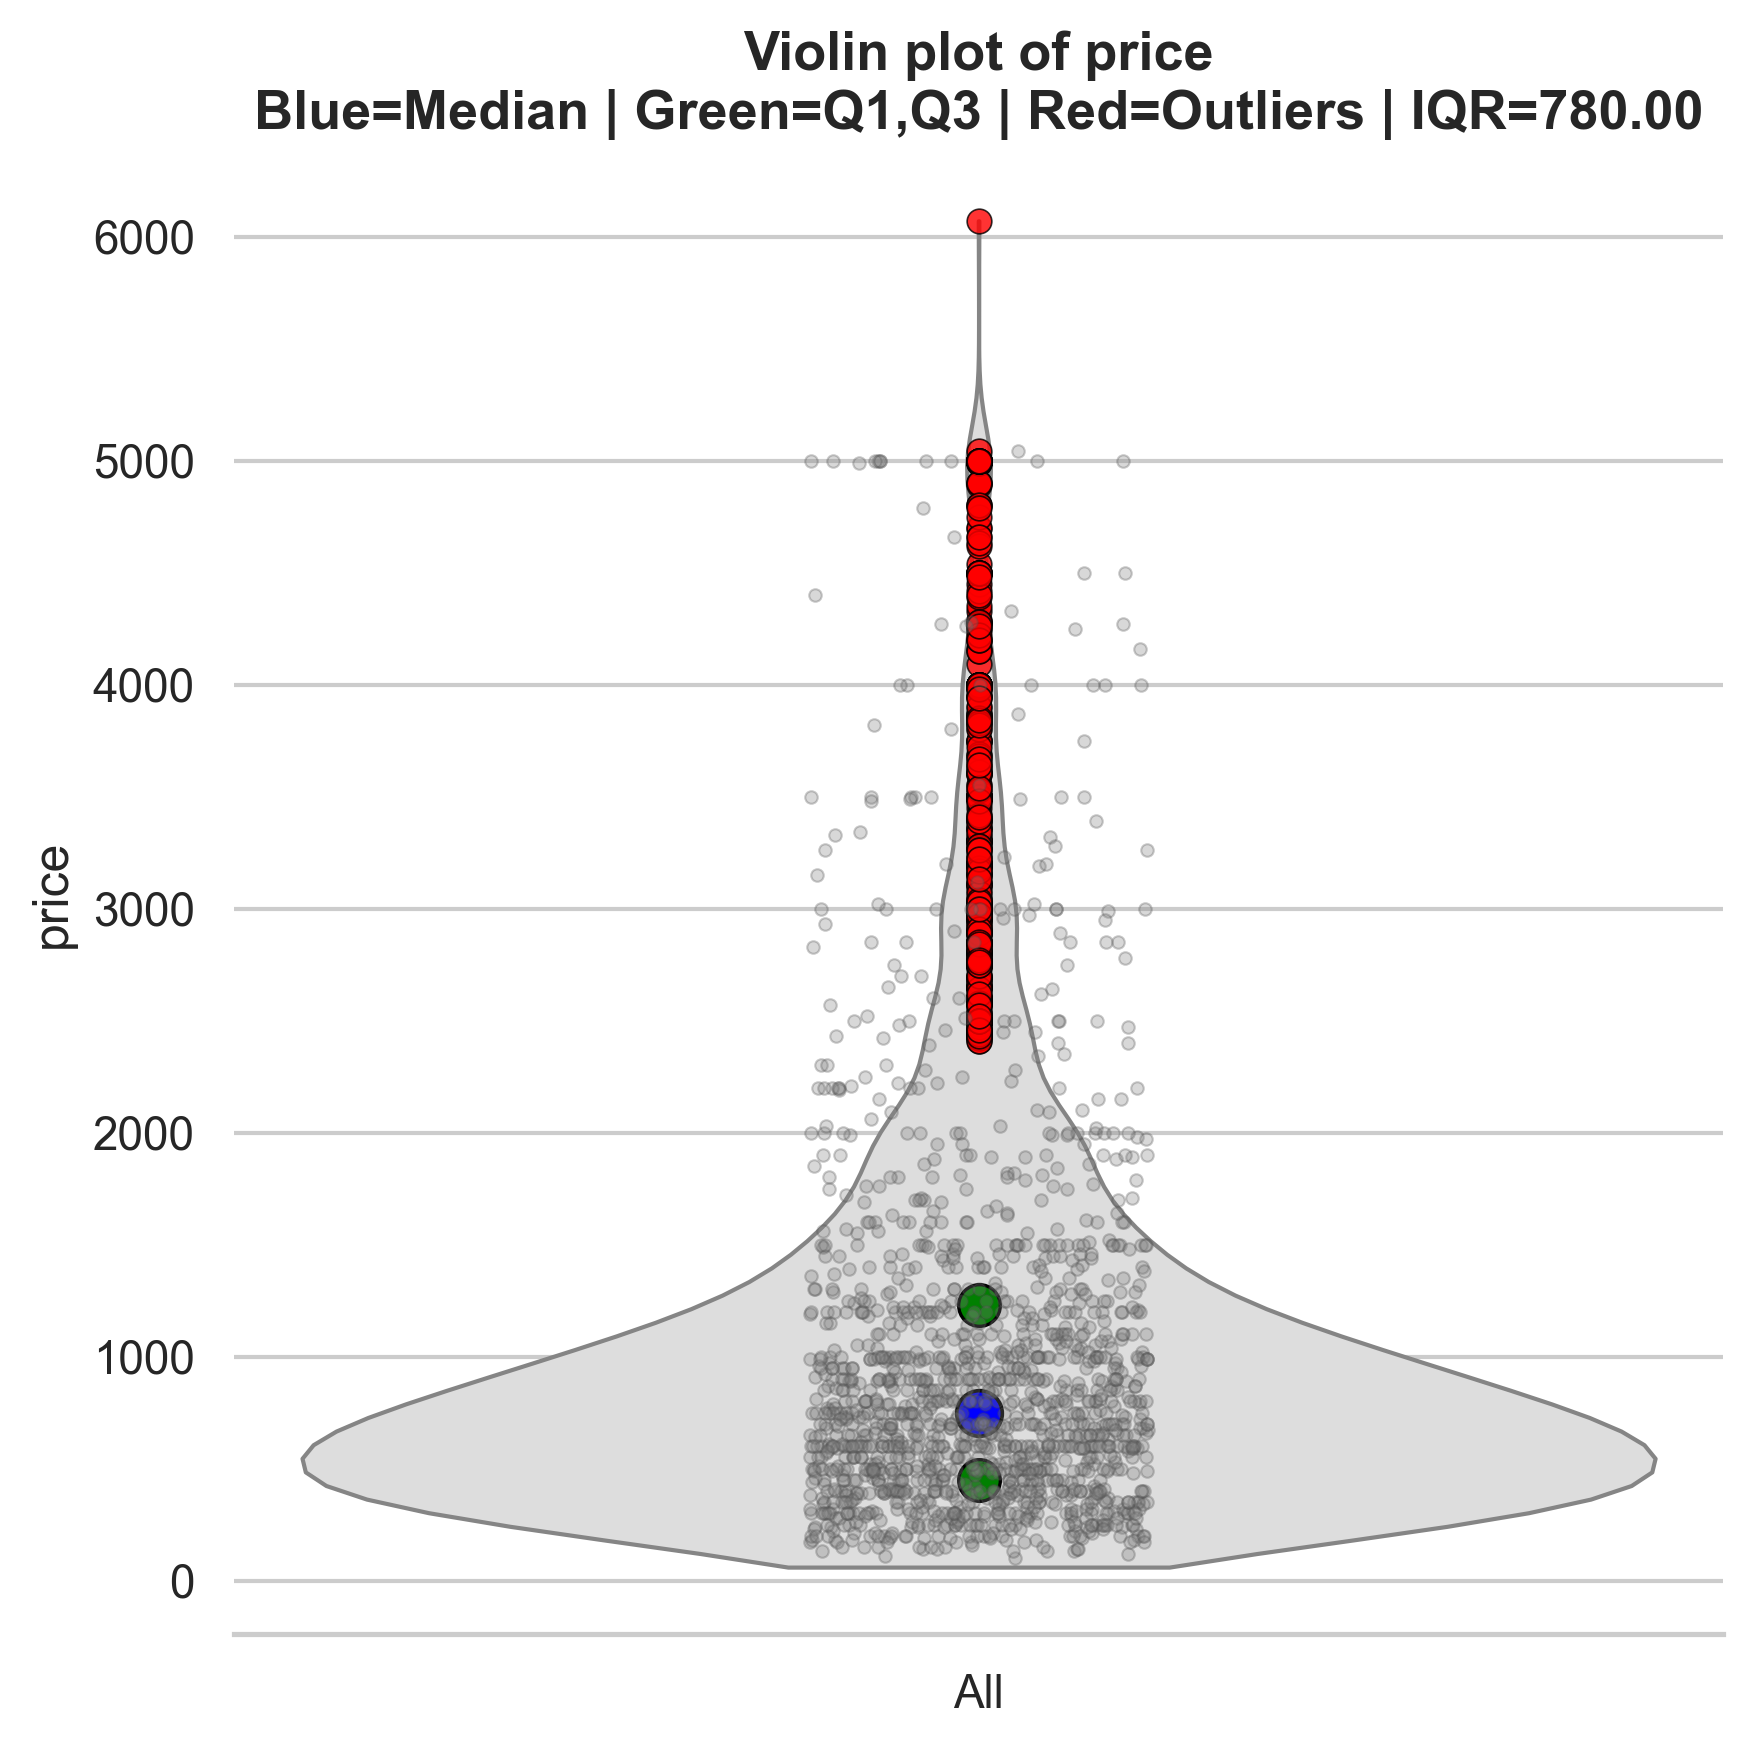

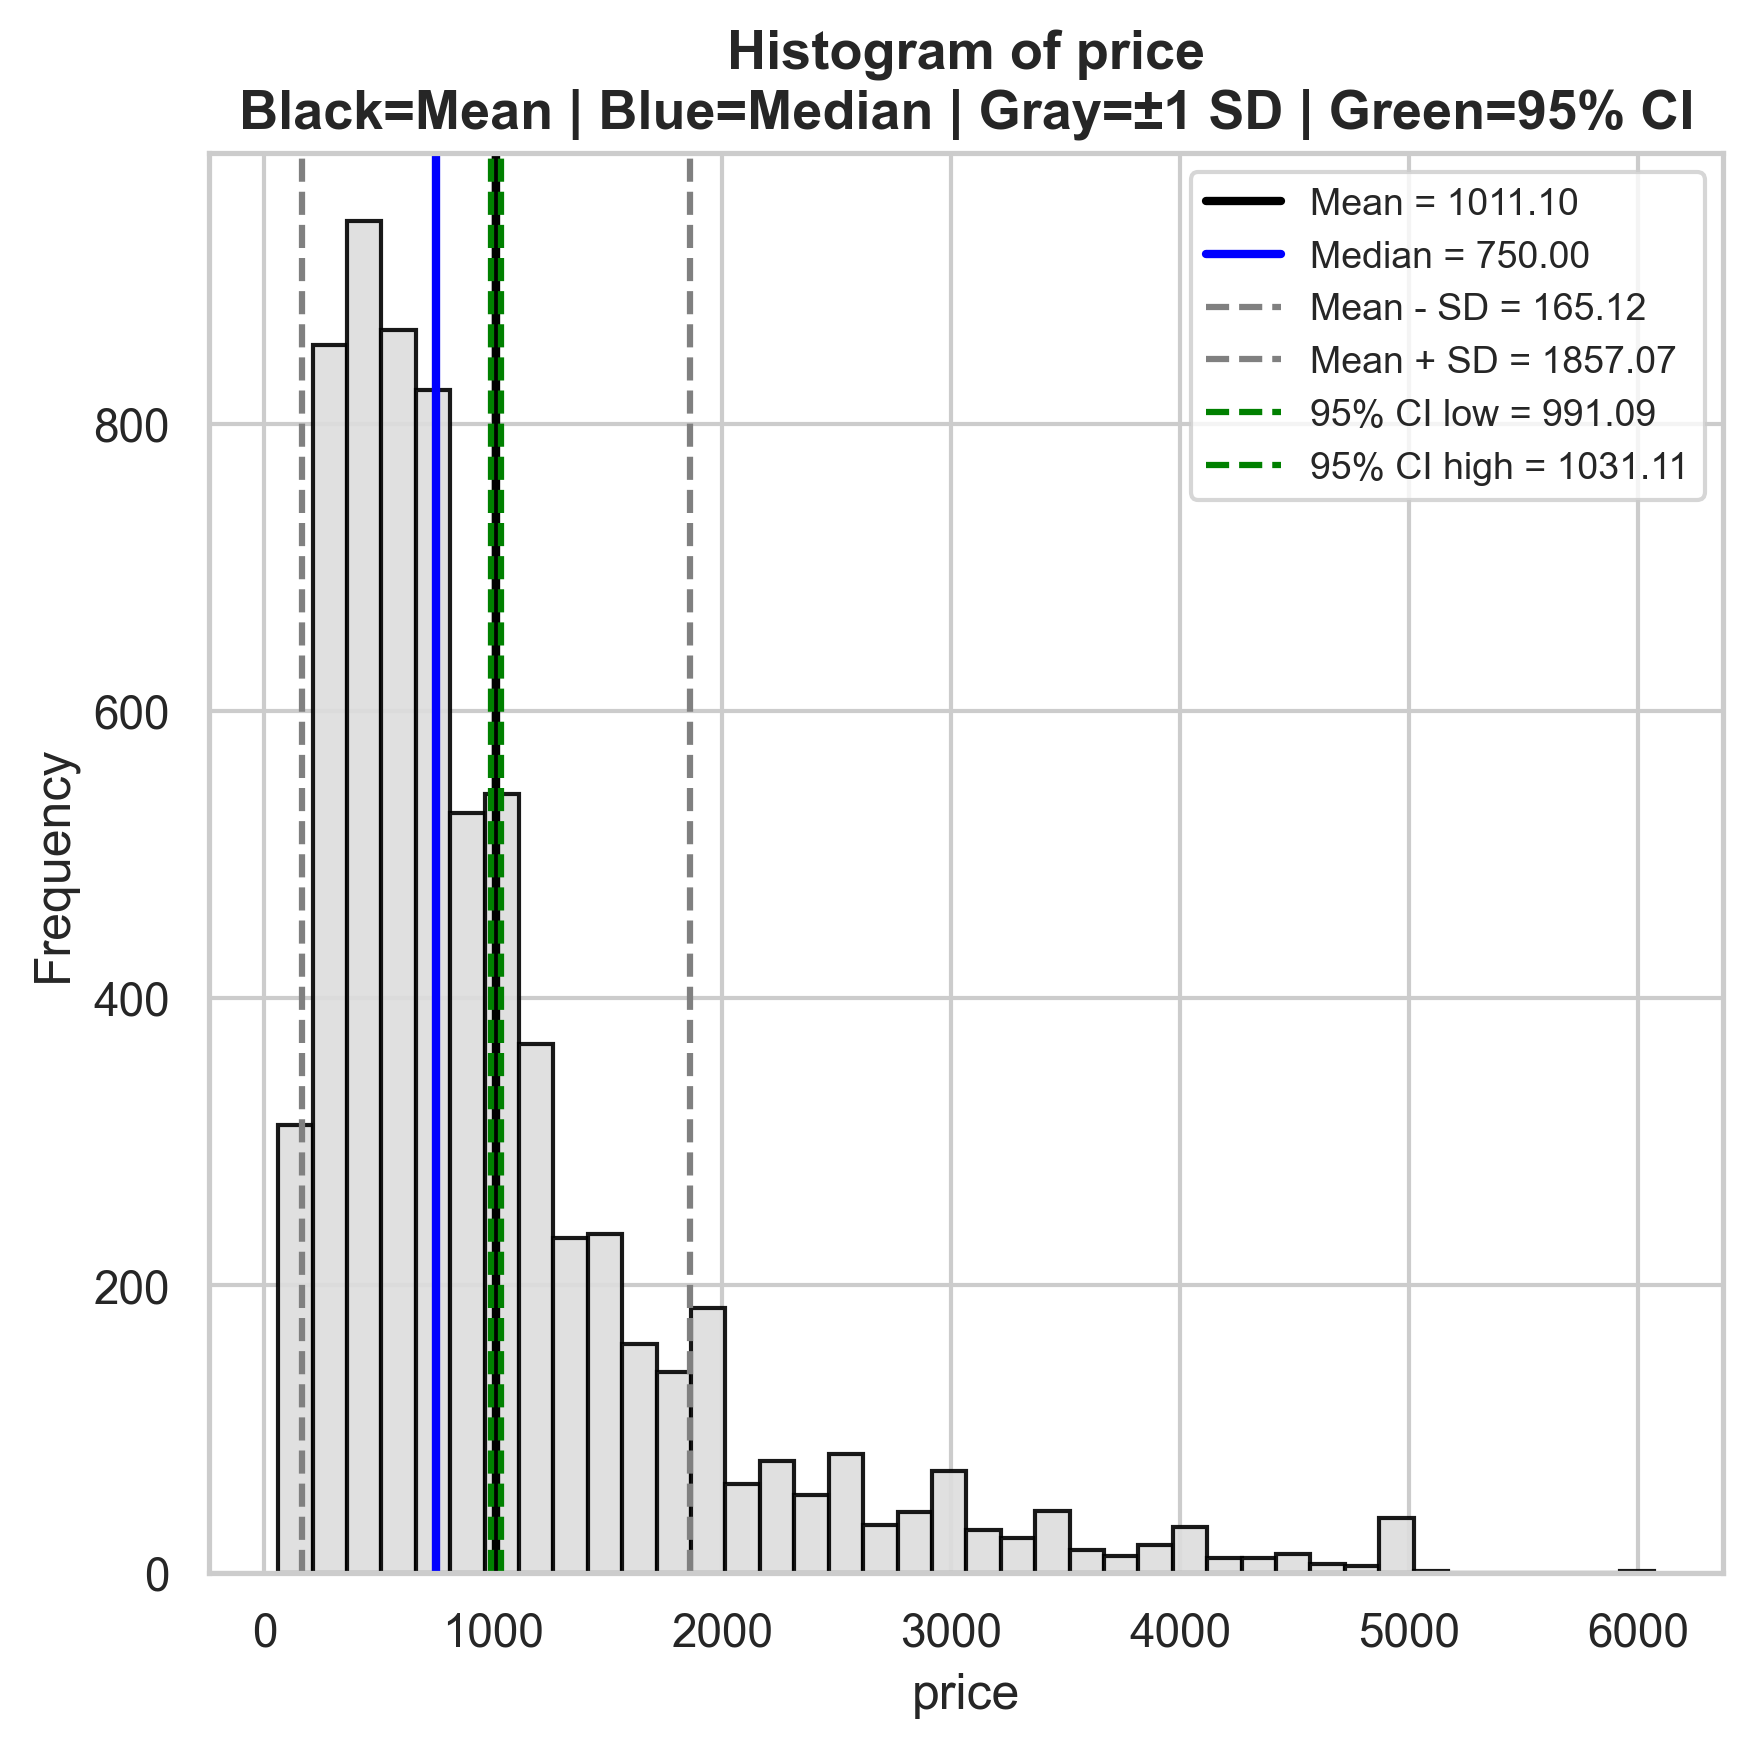

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,price,6870,1011.098108,750.0,845.975377,991.090094,1031.106121,450.0,1230.0,780.0,-720.0,2400.0,509,2.067854,Highly skewed.



Unique values table
Number of non-nulls: 6870
Number of unique values: 383


,column,value,count,frequency_non_null
0,price,60.0,1,0.000146
1,price,80.0,5,0.000728
2,price,90.0,2,0.000291
3,price,100.0,12,0.001747
4,price,110.0,2,0.000291
...,...,...,...,...
378,price,4900.0,3,0.000437
379,price,4990.0,3,0.000437
380,price,5000.0,31,0.004512
381,price,5043.0,1,0.000146



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,price,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,price,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,price,numeric,city,categorical,Chi-square,1436.977564,2.048259e-285,Significant,Statistically significant at p < 0.05.,
3,price,numeric,room_type,categorical,Chi-square,3322.230171,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,price,numeric,accommodates,numeric,Pearson,0.623792,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,price,numeric,bathrooms,categorical,Chi-square,2105.843948,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,price,numeric,bedrooms,categorical,Chi-square,3746.895898,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,price,numeric,beds,numeric,Pearson,0.584479,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,price,numeric,minimum_nights,numeric,Pearson,-0.015838,1.893191e-01,Not significant,Not statistically significant at p < 0.05.,
9,price,numeric,maximum_nights,numeric,Pearson,0.033930,4.914128e-03,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,2.067854,Highly skewed.,Baseline.
1,Log Transformation,0.071785,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.059304,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.002072,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [80]:
analysis = analyze_single_field(df[['neighbourhood_name', 'neighbourhood_district', 'city',
                                     'room_type',  'accommodates', 'bathrooms', 'bedrooms', 'beds',
                                     'price',
                                     'minimum_nights', 'maximum_nights', 'insert_date',
                                     'availability_30', 'availability_60', 'availability_90', 'availability_365',
                                     'number_of_reviews', 'first_review_date', 'last_review_date', 'review_scores_rating', 'review_scores_accuracy',
                                     'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
                                     'review_scores_value', 'reviews_per_month',
                                     'is_instant_bookable' 
                                    ]], 
                                target_col="price", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)


<Axes: xlabel='room_type', ylabel='city'>

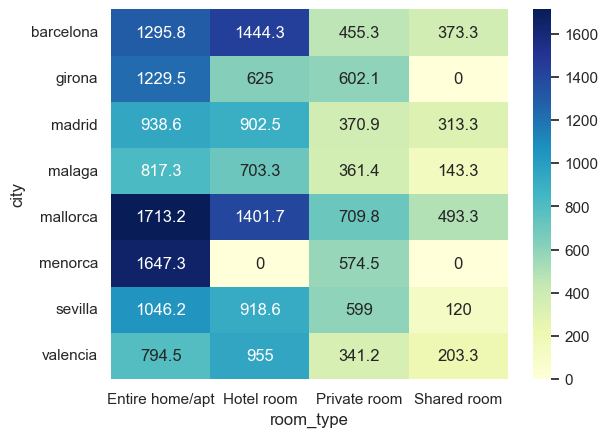

In [77]:
sns.heatmap(df.groupby(['city', 'room_type'])['price'].mean().round(1).unstack(fill_value=0), annot=True, cmap='YlGnBu', fmt='g')